# ZEN Tutorial - Creating Normalised bigWigs

## About

This tutorial explains how to use the package [ZEN-norm](https://github.com/Genome-Function-Initiative-Oxford/Zone-Equalisation-Normalisation/tree/main) - a set of tools for normalising genomic signals. For guidance on reversing prior bigWig normalisation, see the [Reverse Normalisation Tutorial](https://github.com/Genome-Function-Initiative-Oxford/Zone-Equalisation-Normalisation/tree/main/tutorials/zen_tutorials), and to compare performance of genome-wide alignment across normalisation methods, see the [Comparing Normalisation Methods Tutorial](https://github.com/Genome-Function-Initiative-Oxford/Zone-Equalisation-Normalisation/tree/main/tutorials/zen_tutorials).

<a href="https://github.com/Genome-Function-Initiative-Oxford/Zone-Equalisation-Normalisation"><p><img src="https://raw.githubusercontent.com/Genome-Function-Initiative-Oxford/Zone-Equalisation-Normalisation/refs/heads/assets/Images/ZEN_Overview_Figure.png" style="max-width:1000px" width="100%"></p></a>

**Citation:** [T. Wilson, TA. Milne, SG. Riva and JR. Hughes, _Zone Equalisation Normalisation For Improved Alignment of Epigenetic Signal_, bioRxiv, 2025](https://www.biorxiv.org/content/10.64898/2025.12.10.693203v1)

## Table of Contents

1. [ZEN Normalisation Quick Example](#quick-example)
2. [Imports and Set Up](#imports)
3. [Download Example Datasets](#data)
4. [Specifying Input Samples](#input)
    1. [Inputting BAMs](#inputs-bams)
    1. [Inputting bigWigs](#inputs-bigwigs)
5. [Visualising Genomic Signal](#visualisation)
6. [Running ZEN Normalisation](#run-zen)
    1. [Signal Convolution](#run-zen-convolution)
    2. [Distribution Fitting](#run-zen-distribution)
    3. [Zone Prediction](#run-zen-zones)
    4. [Normalised bigWig Generation](#run-zen-norm)

# 1) ZEN Normalisation Quick Example <a id="quick-example"></a>

A basic example to ZEN normalise Day 13 Erythroid ATAC-seq bigWigs is shown below. See the rest of the tutorial for parameter customisation and additional features.

In [ ]:
from ZEN_norm.zone_norm import ZoneNorm

# Set True to use BAMs or False to use bigWigs as input
create_from_bams = False

# Name of output folder
analysis_name = "Erythroid_ATAC"
# Max number of processors to use (set for your system)
cores = 12

if create_from_bams:
    bam_paths = f"Example_Data/{analysis_name}/BAMs"

    # Download publically hosted erythroid ATAC-seq BAMs
    ZoneNorm.downloadFTP(directory = bam_paths, 
                         ftp_paths = ["https://datashare.molbiol.ox.ac.uk/public/project/Wellcome_Discovery/towilson/BAMs/Human/Erythroid/50_Donors_Erythroid/ZEN_T_Wilson_2026/ATAC/hg38/Don002_ATAC_d13_rep1.bam",
                                      "https://datashare.molbiol.ox.ac.uk/public/project/Wellcome_Discovery/towilson/BAMs/Human/Erythroid/50_Donors_Erythroid/ZEN_T_Wilson_2026/ATAC/hg38/Don002_ATAC_d13_rep2.bam"],
                         replace_existing = False)

    # Either create bigWigs without normalisation from BAMs
    ery_atac_znorm = ZoneNorm(analysis_name = analysis_name, # Name of output folder
                              bam_paths = bam_paths, # List or directory of BAM files
                              n_cores = cores, # Number of processors
                              extend_reads = True, # Whether to extend reads during BAM to bigWig mapping
                              filter_strand = False) # Whether to separate by strand (recommended to set as True for transcriptional assays)

else:
    bigwig_paths = f"Example_Data/{analysis_name}/BigWigs"

    # Download publically hosted unnormalised erythroid ATAC-seq bigWigs
    ZoneNorm.downloadFTP(directory = bigwig_paths, 
                         ftp_paths = ["https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM9320nnn/GSM9320314/suppl/GSM9320314%5FDon002%5FATAC%5Fd13%5Frep1.bw",
                                      "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM9320nnn/GSM9320321/suppl/GSM9320321%5FDon003%5FATAC%5Fd13%5Frep1.bw"],
                         replace_existing = False)

    # Or set bigWigs directly
    ery_atac_znorm = ZoneNorm(analysis_name = analysis_name, # Name of output folder
                              bigwig_paths = bigwig_paths, # List or directory of bigWig files
                              n_cores = cores) # Number of processors

# Create smoothed signal
ery_atac_znorm.convolveSignals()
# Test Laplace distribution
ery_atac_znorm.testDistributions()
# Use distribution to predict signal zone coordinates
ery_atac_znorm.predictSignalZones()
# Create normalised bigWigs
ery_atac_znorm.normaliseSignal()

## 2) Imports and Set Up <a id="imports"></a>

Import the ZEN-norm modules, other packages, and global parameters used throughout the notebook. 
* If ZEN-norm is not installed, see the [GitHub repository](https://github.com/Genome-Function-Initiative-Oxford/Zone-Equalisation-Normalisation/tree/main).
* Set `cores` as the number of processors to enable parallelisation.

In [ ]:
import os
import pandas as pd
from ZEN_norm.zone_norm import ZoneNorm

# Human alpha globin locus coordinates
hg38_alpha_globin_coords = {"chrom": "chr16",
                            "start": 160000,
                            "end": 192000}

# CCDC127 and SDHA coordinates
hg38_ccdc127_coords = {"chrom": "chr5",
                       "start": 193000,
                       "end": 262000}

# Max number of processors to use (set for your system)
cores = 12

## 3) Download Example Datasets <a id="data"></a>

Use `downloadFTP` to download publically hosted bigWigs and BAMs:
* Erythroid day 13 donors 2 and 3 ATAC-seq bigWigs and BAMs ([GSE311157](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE311157))
* HeLa TT-seq BAMs ([GSE284682](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE284682))

In [3]:
# Paths to publicly hosted bigWigs
bigwig_ftps = {"Erythroid_ATAC": [f"https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM9320nnn/{gsm}/suppl/{gsm}%5FDon{donor}%5FATAC%5Fd13%5Frep{rep}%2Ebw" for (gsm, donor, rep) in 
                                  ([(f"GSM93203{14 + i}", "002", i + 1) for i in range(7)] + [(f"GSM93203{21 + i}", "003", i + 1) for i in range(7)])]}

# Paths to publicly hosted BAMs
bam_ftps = {"Erythroid_ATAC": [f"https://datashare.molbiol.ox.ac.uk/public/project/Wellcome_Discovery/towilson/BAMs/Human/Erythroid/50_Donors_Erythroid/ZEN_T_Wilson_2026/ATAC/hg38/Don{donor}_ATAC_d13_rep{rep}.bam" for donor in ["002", "003"] for rep in range(1,8)],
            "HeLa_TTseq": [f"https://datashare.molbiol.ox.ac.uk/public/project/Wellcome_Discovery/towilson/BAMs/Human/Cervical_Carcinoma/HeLa_TT-seq_A_Fiszbein_2024/hg38_sacCer3/HeLa_TTseq_Control_Rep{rep}.bam" for rep in range(1,4)]}

In [4]:
# Download bigWigs per dataset
for data in bigwig_ftps:
    ZoneNorm.downloadFTP(directory = f"Example_Data/{data}/BigWigs", 
                         ftp_paths = bigwig_ftps[data],
                         n_threads = cores,
                         replace_existing = False)
    
# Download BAMs per dataset
for data in bam_ftps:
    ZoneNorm.downloadFTP(directory = f"Example_Data/{data}/BAMs", 
                         ftp_paths = bam_ftps[data],
                         n_threads = cores,
                         replace_existing = False)

## 4) Specifying Input Samples <a id="inputs"></a>

`ZoneNorm` runs on genomic signals from either BAMs or bigWigs.
* Inputting BAMs is preferred to ensure samples to compare are processed in the same way.
* If BAMs are given, they are automatically mapped to bigWigs.
* If bigWigs are given, see the [Reverse Normalisation Tutorial](https://github.com/Genome-Function-Initiative-Oxford/Zone-Equalisation-Normalisation/tree/main/tutorials/zen_tutorials) if they are pre-normalised or to test for prior normalisation.

### 4.1) Inputting BAMs <a id="inputs-bams"></a>

To generate bigWigs from BAMs, initialise `ZoneNorm` with the following key parameters:

| Parameter | Description | Usage |
|------------|-------------|-------------|
| **`analysis_name`** | Custom output folder name. | Recommended. Defaults to saving results to a folder named `Analysis` created in the current working directory. |
| **`bam_paths`** | List or directory of `.bam` files. | Required unless `bigwig_paths` is given (see [Inputting bigWigs](#inputs-bigwigs)). |
| **`n_cores`** | Number of processors to use. | Defaults to one core. |
| **`norm_method`** | Specifies how bigWig files should be normalised. Settable as `ZEN` for ZEN normalisation, or `None` to creates raw bigWigs (which are also created with `ZEN` if BAMs are given). Other options include deepTools methods (`RPKM`, `CPM`, `BPM`, `RPGC`), spike-in normalisation (`RRPM`) and `Scalar` to use custom scaling factors. | Defaults to `ZEN`. |
| **`extend_reads`** | Set as `True` to enable read extension during bigWig creation. | Defaults to `False`. |
| **`filter_strand`** | Setting this as `True` will split a BAM into forward and reverse strand bigWigs, or setting `forward` or `reverse` will keep only one strand. | Defaults to `False` to disables strand filtering. |
| **`genome_size`** | Set as the name of a genome (e.g. `hg38`) or an integer (e.g. 2913022398). | Required only if using `RPGC` normalisation. |
| **`spikein_prefix`** | If spike-in was used and BAMs mapped to a combined genome are given, this can be set as the chromosome name prefix to separate chromosomes by organism. | Required only if using `RRPM` normalisation. |
| **`scaling_factors`** |  If norm_method is set as `Scalar`, set this as a number to multiple all samples signal by, or a dictionary mapping sample names to numbers. | Required only if using `Scalar` normalisation. |
| **`blacklist`** | Path to blacklist file with chromosome coordinates to exclude. | No blacklist set by default. |

##### Non-Transcriptional Assay Example - Erythroid ATAC-seq <a id="bam-to-bigwig-ery-atac-example"></a>

Create unnormalised erythroid ATAC-seq bigWigs and set to ZEN normalise.
* Read extension is optional and depends on user preference.

In [ ]:
data = "Erythroid_ATAC"

# Create raw bigWigs
ery_atac_znorm = ZoneNorm(analysis_name = data,
                          bam_paths = f"Example_Data/{data}/BAMs", 
                          n_cores = cores,
                          norm_method = "ZEN",
                          extend_reads = True)

# Show set samples and parameters
print(ery_atac_znorm)

##### Transcriptional Assay Example - HeLa TT-seq

Create unnormalised forward and reverse strand separated HeLa TT-seq bigWigs and set to ZEN normalise.
* Strand filtering is enabled as TT-seq is a transcriptional assay.
* As an RNA spike-in was used, BAMs were mapped to a [SeqNado](https://pypi.org/project/seqnado/) combined human and yeast genome.
* Yeast chromosomes are labelled with the `sacCer3` prefix (e.g. `sacCer3_chrI`, `sacCer3_chrII`).

In [ ]:
data = "HeLa_TTseq"

# Create raw bigWigs
hela_ttseq_znorm = ZoneNorm(analysis_name = "HeLa_TTseq",
                            bam_paths = f"Example_Data/{data}/BAMs", 
                            n_cores = cores,
                            norm_method = "ZEN",
                            filter_strand = True,
                            spikein_prefix = "sacCer3")

# Show set samples and parameters
print(hela_ttseq_znorm)

### 4.2) Inputting bigWigs <a id="inputs-bigwigs"></a>

If inputting bigWigs rather than BAMs, initialise `ZoneNorm` with the following key parameters:
| Parameter | Description | Usage |
|------------|-------------|-------------|
| **`analysis_name`** | Custom output folder name. | Recommended. Defaults to saving results to a folder named `Analysis` created in the current working directory. |
| **`bigwig_paths`** | List or directory of `.bw` and/or `.bigWig` files. | Required unless `bam_paths` is given (see [Inputting BAMs](#inputs-bams)). |
| **`n_cores`** | Number of processors to use. | Defaults to one core. |
| **`norm_method`** | Specifies how bigWig files should be normalised. Settable as `ZEN` for ZEN normalisation, or `None` to creates raw bigWigs (which are also created with `ZEN` if BAMs are given). Other options include deepTools methods (`RPKM`, `CPM`, `BPM`, `RPGC`), spike-in normalisation (`RRPM`) and `Scalar` to use custom scaling factors. | Defaults to `ZEN`. |
| **`blacklist`** | Path to blacklist file with chromosome coordinates to exclude. | No blacklist set by default. |

##### Erythroid ATAC-seq Example

Equivalent to the erythroid ATAC-seq example in the section above, but requires bigWigs to have already been created.

In [2]:
data = "Erythroid_ATAC"

# Set pre-existing bigWigs for downstream analysis
ery_atac_znorm = ZoneNorm(analysis_name = data,
                          bigwig_paths = f"Example_Data/{data}/BigWigs", 
                          n_cores = cores,
                          norm_method = "ZEN")

# Show set samples and parameters
print(ery_atac_znorm)

Opening 14 bigWig files
Setting chromosomes as autosomal and sex chromosomes
ZoneNorm object for "Erythroid_ATAC"
   * Output directory: /ceph/project/Wellcome_Discovery/towilson/Projects/ZEN-norm/PyPI/tests/Erythroid_ATAC
   * 24 chromosome(s): chr1, chr2, chr3, chr4, chr5, chr6, chr7, chr8, chr9, chr10, chr11, chr12, chr13, chr14, chr15, chr16, chr17, chr18, chr19, chr20, chr21, chr22, chrX, chrY
   * Number of samples: 14
   * Sample names: GSM9320314_Don002_ATAC_d13_rep1, GSM9320315_Don002_ATAC_d13_rep2, GSM9320316_Don002_ATAC_d13_rep3, GSM9320317_Don002_ATAC_d13_rep4, GSM9320318_Don002_ATAC_d13_rep5, GSM9320319_Don002_ATAC_d13_rep6, GSM9320320_Don002_ATAC_d13_rep7, GSM9320321_Don003_ATAC_d13_rep1, GSM9320322_Don003_ATAC_d13_rep2, GSM9320323_Don003_ATAC_d13_rep3, GSM9320324_Don003_ATAC_d13_rep4, GSM9320325_Don003_ATAC_d13_rep5, GSM9320326_Don003_ATAC_d13_rep6, GSM9320327_Don003_ATAC_d13_rep7
   * Blacklist: Not set
   * Strand filtering: No strand filtering when converting BAMs to 

## 5) Visualising Genomic Signal <a id="visualisation"></a>

Genomic signal regions can be visualised using `plotTracks`.

| Parameter | Description | Usage |
|------------|-------------|-------------|
| **`chromosome`** | Chromosome name, e.g. `chr1`. | Required. |
| **`start_coord`** | Start coordinate. | Required. |
| **`end_coord`** | End coordinate. | Required. |
| **`bar_regions`** | List of arrays of coordinates of peaks / zones / regions to plot as bars at the top. | No bars shown by default. |
| **`plot_samples`** | List of samples to plot. | If not specified, all samples will be plotted. |
| **`plot_labels`** | List of custom sample labels. | By default, labels are set as sample names. |
| **`custom_colours`** | List of colours to map to samples, or string to use same colour for all samples. | If not specified, default colours are used. |
| **`overlay_plots`** | Set as `True` to plot sample signals on top of one another, or `False` for sub-plots. | Defaults to `False`. |
| **`main_title`** | Custom title to display above plot. | No title if not set. |
| **`pdf_name`** | If provided, the plot will be saved as a PDF with this name. | By default, plot is displayed but not saved. |

##### Erythroid ATAC-seq Example

View unnormalised signal over the alpha-globin locus for two replicates.

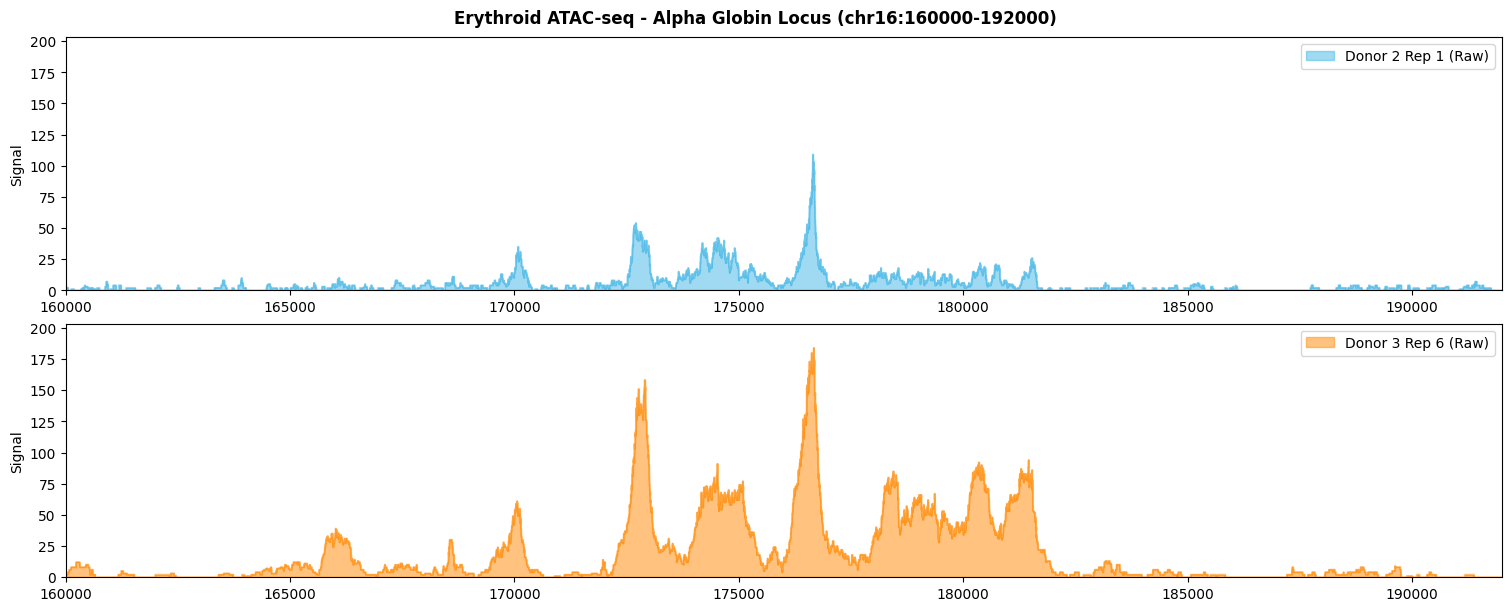

In [3]:
# Plot raw signal for two samples
title = f"Erythroid ATAC-seq - Alpha Globin Locus "
title += f"({hg38_alpha_globin_coords['chrom']}:{hg38_alpha_globin_coords['start']}-{hg38_alpha_globin_coords['end']})"

ery_atac_znorm.plotTracks(chromosome = hg38_alpha_globin_coords["chrom"], # Chromosome coordinates to plot
                          start_coord = hg38_alpha_globin_coords["start"],
                          end_coord = hg38_alpha_globin_coords["end"],
                          plot_samples = ["GSM9320314_Don002_ATAC_d13_rep1", "GSM9320326_Don003_ATAC_d13_rep6"], # Sample names
                          plot_labels = ["Donor 2 Rep 1 (Raw)", "Donor 3 Rep 6 (Raw)"], # Custom labels
                          custom_colours = ["#41B6E6", "#FF8800"], # Hex colour codes, with one per sample
                          overlay_plots = False, # False to plot signals separately
                          main_title = title)

##### HeLa TT-seq Example

View forward and reverse strand-separated signal over _CCDC127_ and _SDHA_

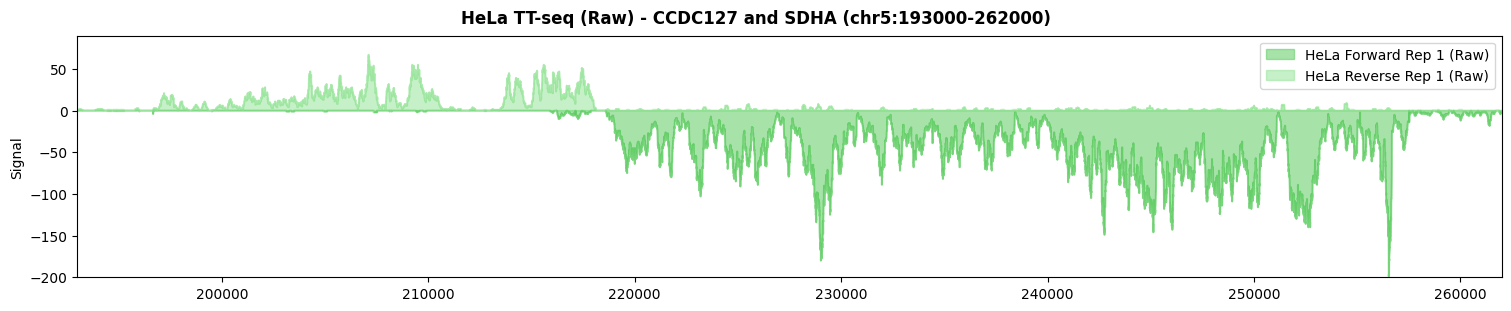

In [5]:
# Plot raw signal
title = f"HeLa TT-seq (Raw) - CCDC127 and SDHA "
title += f"({hg38_ccdc127_coords['chrom']}:{hg38_ccdc127_coords['start']}-{hg38_ccdc127_coords['end']})"

hela_ttseq_znorm.plotTracks(chromosome = hg38_ccdc127_coords["chrom"],
                            start_coord = hg38_ccdc127_coords["start"],
                            end_coord = hg38_ccdc127_coords["end"],
                            plot_samples = ["HeLa_TTseq_Control_Rep1_Pos", "HeLa_TTseq_Control_Rep1_Neg"],
                            plot_labels = ["HeLa Forward Rep 1 (Raw)", "HeLa Reverse Rep 1 (Raw)"],
                            custom_colours = ["#51C955", "#8FE392"],
                            overlay_plots = True,
                            main_title = title)

## 6) Running ZEN Normalisation <a id="run-zen"></a>

After inputting BAMs or bigWigs to `ZoneNorm`, ZEN normalised bigWigs for any assay can be created in several steps:
1. [Signal convolution](#run-zen-convolution)
2. [Distribution fitting](#run-zen-distribution)
3. [Signal zone prediction](#run-zen-zones)
4. [Normalised bigWig generation](#run-zen-norm)

### 6.1) Signal Convolution <a id="run-zen-convolution"></a>

To help separate biological signal from noise during zone prediction, a smoothed version of the signal is created via convolution with a kernel.
* Smoothing reduces the influence of local fluctuations.
* This is an intermediate step and ZEN normalised bigWigs are not directly created from this signal.

#### 6.1.1) Smoothing Kernel

<ins>Default Smoothing Kernel (Recommended)</ins>

The default is a triangular kernel $\hat{\kappa}_{n}$ with size $n = 301$ bp.

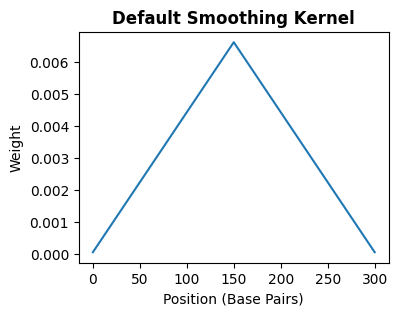

In [4]:
# Get the default 301 bp triangle kernel
default_kernel = ZoneNorm.createTriangleKernel(size = 301)
# View the kernel
ery_atac_znorm.plotKernel(kernel = default_kernel, title = "Default Smoothing Kernel")

<ins>Custom Kernels</ins>

The kernel can be overwritten during initialisation of `ZoneNorm` or using method `setKernel` with parameter:

| Parameter | Description | Usage |
|------------|-------------|-------------|
| **`kernel`** | List or array of numerical values representing a kernel. | Defaults to a 301 bp triangular kernel. |


##### Gaussian Kernel Example

In this example, a `ZoneNorm` object is created to demonstrate how a custom Gaussian kernel can be set.

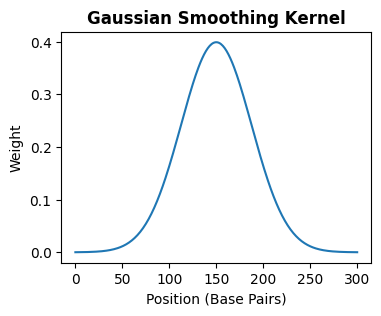

In [7]:
data = "Erythroid_ATAC"

# Create normal distribution kernel
gaussian_kernel = ZoneNorm.createGaussianKernel(mean = 0, sd = 1, size = 301)

# Set kernel during initialisation
gaussian_znorm = ZoneNorm(analysis_name = "Kernel_Test",
                          bigwig_paths = f"Example_Data/{data}/BigWigs", 
                          n_cores = cores,
                          norm_method = "ZEN",
                          kernel = gaussian_kernel,
                          verbose = 0)

# Or set kernel after initialisation (in this case redundant as already set above)
gaussian_znorm.setKernel(gaussian_kernel)

# View the kernel
gaussian_znorm.plotKernel(title = "Gaussian Smoothing Kernel")

#### 6.1.2) Running Signal Convolution

After setting the kernel (or using the default), run `convolveSignals` to smooth the signal.

| Parameter | Description | Usage |
|------------|-------------|-------------|
| **`chromosomes`** | List or array of chromosomes to run convolution for. | By default, all chromosomes are used. |
| **`replace_existing`** | If `True`, existing output files will be recreated. If `False`, only missing files will be generated without overwriting existing ones. | `False` by default. Set as `True` if a previous run was interrupted and produced incomplete or corrupt files. |

##### Erythroid ATAC-seq Example

In [4]:
# Create smoothed signal
ery_atac_znorm.convolveSignals()

Signal, smoothed signal and missing signal already created for chromosomes


#### 6.1.3) Saving Smoothed Signal to bigWigs

Although not essential, smoothed signal can be saved to bigWigs with `createSmoothBigWigs`.

| Parameter | Description | Usage |
|------------|-------------|-------------|
| **`sample_names`** | List of sample names to save bigWigs for. | Defaults to saving bigWigs for all samples. |
| **`replace_existing`** | If `True`, existing output files will be recreated. If `False`, only missing files will be generated without overwriting existing ones. | `False` by default. Set as `True` if a previous run was interrupted and produced incomplete or corrupt files. |

##### Erythroid ATAC-seq Example

Saving smoothed signal to bigWig allows it to be plotted or viewed in a genome browser.

In [3]:
# Save convolved signals to bigWigs
ery_atac_znorm.createSmoothBigWigs()

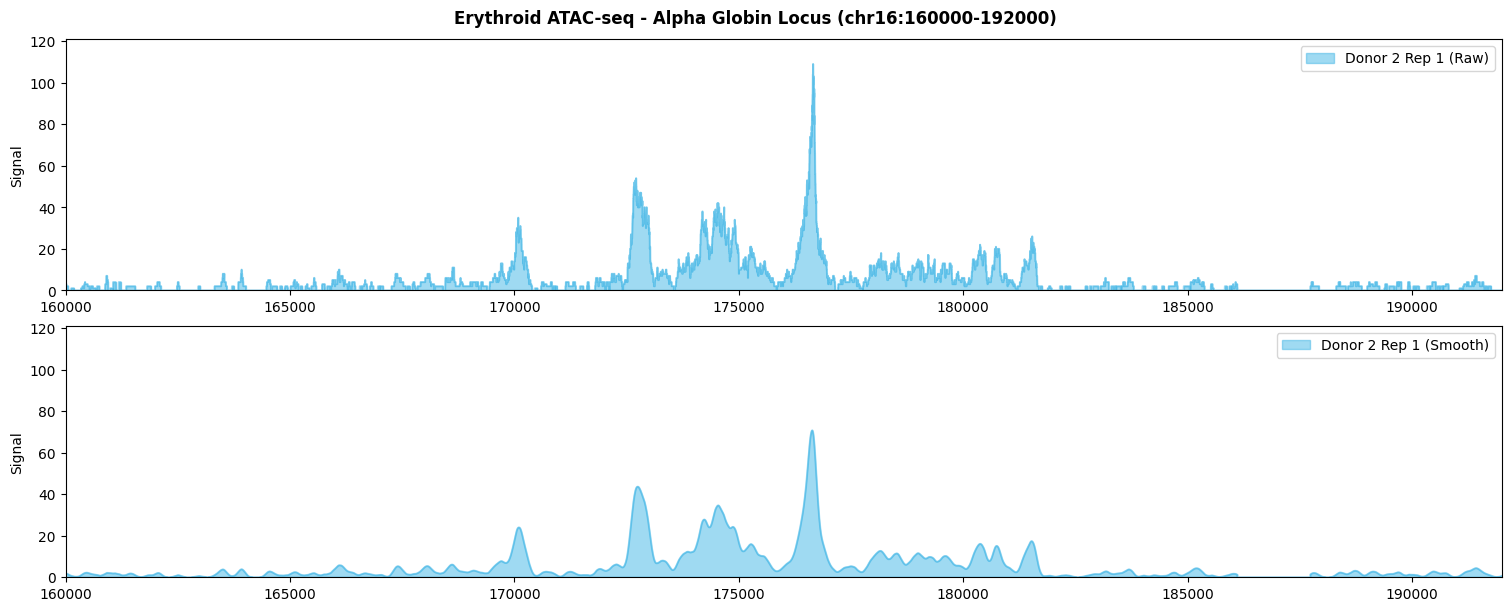

In [25]:
# Plot smoothed signal
title = f"Erythroid ATAC-seq - Alpha Globin Locus "
title += f"({hg38_alpha_globin_coords['chrom']}:{hg38_alpha_globin_coords['start']}-{hg38_alpha_globin_coords['end']})"

ery_atac_znorm.plotTracks(chromosome = hg38_alpha_globin_coords["chrom"],
                          start_coord = hg38_alpha_globin_coords["start"],
                          end_coord = hg38_alpha_globin_coords["end"],
                          plot_bigwigs = ["Example_Data/Erythroid_ATAC/BigWigs/GSM9320314_Don002_ATAC_d13_rep1.bw",
                                          "Erythroid_ATAC/Results/BigWigs/Smooth/GSM9320314_Don002_ATAC_d13_rep1_smooth.bw"],
                          plot_labels = ["Donor 2 Rep 1 (Raw)", "Donor 2 Rep 1 (Smooth)"],
                          custom_colours = "#41B6E6",
                          overlay_plots = False,
                          main_title = title)

#### 6.1.2) Signal Summary Statistics

After convolution, `getSignalStats` can be used to view summary statistics calculated from sample signal for the chromosome:

| Statistic | Notation | Description |
| ----------| -------- | ----------- |
| `fragmentEstimate` | $\hat{f_{c}}$ | Estimated fragment size, i.e. the smallest non-zero value in the signal |
| `coverage`         | $\mathrm{coverage}({Y_{c}})$ | Number of bps in the signal |
| `sum`              | $\sum{Y_{c}}$ | Sum of all values in the signal |
| `mean`             | $\mathrm{Mean}(Y_{c})$ | Signal mean |
| `median`           | $\mathrm{Median}(Y_{c})$ | Signal median |
| `SD`               | $\mathrm{SD}(Y_{c})$ | Signal standard deviation |
| `MAD`              | $\mathrm{MAD}({Y_{c}})$ | Signal median average deviation |
| `meanAD`           | $\mathrm{MeanAD}({Y_{c}})$ | Signal mean average deviation |

Where $c$ denotes a chromosome and $Y_{c}$ is sample signal for the chromosome.

* After convolution, $Y_{c}$ is either the full signal across $c$ (`signal`), or signal across $c$ after removing zeros (`non_zero_signal`).
* After distribution fitting and zone prediction, more rows are added for different $Y_{c}$ signals.

##### Erythroid ATAC-seq Example

In [ ]:
# Show statistics calculated per sample and chromosome
stats_df = ery_atac_znorm.getSignalStats()
stats_df

,sample,chrom,signal_type,fragmentEstimate,coverage,sum,mean,median,SD,MAD,meanAD
0,GSM9320314_Don002_ATAC_d13_rep1,chr1,signal,1.0,91675301,356722976.0,1.432873,0.0,80.300217,0.0,1.831073
1,GSM9320314_Don002_ATAC_d13_rep1,chr1,signal_non_zero,1.0,91675301,356722784.0,3.891155,2.0,132.303955,0.0,2.871654
7,GSM9320314_Don002_ATAC_d13_rep1,chr2,signal,1.0,94756955,268228624.0,1.107497,0.0,7.144077,0.0,1.353933
8,GSM9320314_Don002_ATAC_d13_rep1,chr2,signal_non_zero,1.0,94756955,268228864.0,2.830704,2.0,11.205874,0.0,1.330808
14,GSM9320314_Don002_ATAC_d13_rep1,chr3,signal,1.0,78580883,232872560.0,1.174371,0.0,32.746136,0.0,1.426792
...,...,...,...,...,...,...,...,...,...,...,...
2332,GSM9320327_Don003_ATAC_d13_rep7,chr22,signal_non_zero,1.0,16096387,75551096.0,4.693668,2.0,14.821927,0.0,3.870255
2338,GSM9320327_Don003_ATAC_d13_rep7,chrX,signal,1.0,46910152,161378272.0,1.034205,0.0,6.374823,0.0,1.447931
2339,GSM9320327_Don003_ATAC_d13_rep7,chrX,signal_non_zero,1.0,46910152,161378688.0,3.440166,2.0,11.265035,0.0,2.256680
2345,GSM9320327_Don003_ATAC_d13_rep7,chrY,signal,1.0,6234850,22717648.0,0.396971,0.0,6.274435,0.0,0.707445


### 6.2) Distribution Fitting <a id="run-zen-distribution"></a>

After convolution, distributions are fitted to a transformed version of the smoothed signal. Later, sample-specific thresholds are dervived from these to separate enriched signal from background noise.

#### 6.2.1) Signal Tranformation

Histograms of raw and smoothed signal per chromosome for most genomic assays are typically skewed, reflecting low signal-to-noise ratios. As such distributions are not well suited for parametric fitting, a transformed version of the smooth signal is created by removing zeros and log-transformation to reduce skew.

##### Erythroid ATAC-seq Example

For example, in the histogram of smoothed chromosome signal for a erythroid ATAC-seq replicate most signal is near zero. Removing zeros and log-transforming the signal makes it symmetrical.

Reading chr9:0-138394717 for GSM9320314_Don002_ATAC_d13_rep1


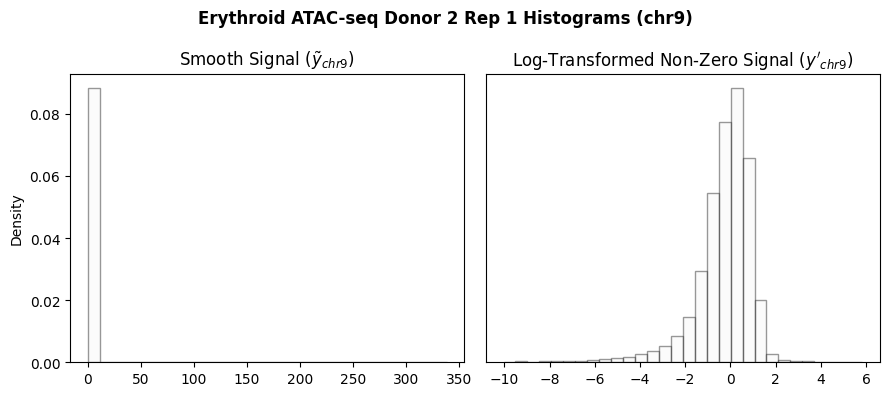

In [3]:
sample_name = "GSM9320314_Don002_ATAC_d13_rep1"
chromosome = "chr9"

ery_atac_znorm.plotTransformedSignal(plot_sample = sample_name, 
                                     chromosome = chromosome, 
                                     title = f"Erythroid ATAC-seq Donor 2 Rep 1 Histograms ({chromosome})",
                                     pdf_name = f"{sample_name}_Histograms")

#### 6.2.2) Testing Distributions

To estimate distribution parameters (location $L_{c}$ and scale $V_{c}$) to fit to each transformed signal, candidate distributions are fitted and their goodness-of-fit measured via `testDistributions`. Down-sampling may be applied to the transformed signal to improve computational efficiency.

| Parameter | Description | Usage |
|------------|-------------|-------------|
| **`chromosomes`** | List or array of chromosomes to test distribution for. | By default, all chromosomes are used. |
| **`log_transform`** | `True` to apply log-transformation to signal before fitting distributions, or `False` for no log-tranformation. | Log-transformation is recommended. If unset, the value is derived from the `ZoneNorm` instance. |
| **`downsample_size`** | Number of values ($\delta$) to down-sample tranformed signal to. | By default, 300 values are used. |
| **`replace_existing`** | If `True`, existing output files will be recreated. If `False`, only missing files will be generated without overwriting existing ones. | `False` by default. Set as `True` if a previous run was interrupted and produced incomplete or corrupt files. |

<ins>Default Distribution (Recommended)</ins>

The Laplace distribution is sufficient for most assays, and so by default only parameters for Laplace are tested.

<ins>Other Distributions</ins>

All two parameter SciPy distributions are supported: Normal, Laplace, Logistic, Cauchy, left skewed Gumbell and right skewed Gumbel. To get their names, `getSupportedDistributions` can be used.

In [4]:
# View all supported distributions
print("Supported distributions:", ZoneNorm.getSupportedDistributions())

Supported distributions: ['norm', 'laplace', 'logistic', 'cauchy', 'gumbel_l', 'gumbel_r']


A custom list of distributions can be specified during initialisation of `ZoneNorm`, or using `setTestDistributions` with parameter:

| Parameter | Description | Usage |
|------------|-------------|-------------|
| `test_distributions` | List of statistical distributions to evaluate by their fit to the tranformed signal. | Set only if you want to evalulate additional distributions. By default, only Laplace is tested as this is suitable for most datasets. |


<ins>Distribution Parameter Types</ins>


Three parameter types to set ($L_{c}$, $V_{c}$) are tested per distribution:
| Name | Location ($L_{c}$) | Scale ($V_{c}$) |
|------------|-------------|-------------|
| Mean fit | $\mathrm{Mean}(\tilde{y}'_c)$ | $\mathrm{SD}(\tilde{y}'_c)$ |
| Median fit | $\mathrm{Median}(\tilde{y}'_c)$ | $\alpha_d \operatorname{MAD}(\tilde{y}'_c)$ if $\neq 0$, else $\beta_d \operatorname{MeanAD}(\tilde{y}'_c)$ |
| SciPy fit | Inferred by SciPy | Inferred by SciPy |

Where:
* $\tilde{y}'_c$ is the transformed (optionally down-sampled) signal for a chromosome $c$
* $\alpha_d$ and $\beta_d$ are pre-determined distribution-specific constants

In [5]:
print("Supported parameter types:", ZoneNorm.getSupportedParamTypes())

Supported parameter types: ['scipy_fit', 'mean_fit', 'median_fit']


##### Erythroid ATAC-seq Example

Deviating from the default distribution is generally not necessary. But for demonstrative purposes, this example tests all supported distributions.

In [6]:
# Set to test additional distributions (not required)
ery_atac_znorm.setTestDistributions(test_distributions = ["norm", "logistic", "laplace", "gumbel_l", "gumbel_r", "cauchy"])

# Run to test distributions (required)
ery_atac_znorm.testDistributions()

Distribution statistics already calculated for chromosomes


#### 6.2.3) Viewing Distribution Fitting Statistics

Statistics calculated per chromosome, sample, distribution and parameter type ($L_{c}$, $V_{c}$) can be retrieved by `getDistributionStats`. 

| Statistic |  Description |
| ----------| -------- |
| `KS_stat` | Test statistic of the Kolmogorov–Smirnov test |
| `KS_p_value` | Kolmogorov–Smirnov test p-value |
| `BIC` | Bayesian information criterion |
| `AIC` | Akaike information criterion |
| `log_likelihood` | Log likelihood |

##### Erythroid ATAC-seq Example

In [9]:
# Get distribution fitting statistics
dist_df = ery_atac_znorm.getDistributionStats()
dist_df

,sample,chrom,distribution,param_type,AIC,BIC,KS_p_value,KS_stat,location,log_likelihood,scale
0,GSM9320314_Don002_ATAC_d13_rep1,chr1,cauchy,scipy_fit,968.531087,975.938652,3.873967e-03,0.101401,0.060879,-482.265543,0.560124
1,GSM9320314_Don002_ATAC_d13_rep1,chr1,cauchy,mean_fit,1095.412900,1102.820465,2.209112e-09,0.184204,-0.235759,-545.706450,1.261154
2,GSM9320314_Don002_ATAC_d13_rep1,chr1,cauchy,median_fit,970.205374,977.612939,7.690462e-03,0.095654,-0.006248,-483.102687,0.558016
3,GSM9320314_Don002_ATAC_d13_rep1,chr1,logistic,scipy_fit,943.252401,950.659966,6.013692e-02,0.075848,-0.091336,-469.626201,0.629232
4,GSM9320314_Don002_ATAC_d13_rep1,chr1,logistic,mean_fit,951.257678,958.665243,9.596475e-05,0.127999,-0.235759,-473.628839,0.695311
...,...,...,...,...,...,...,...,...,...,...,...
6043,GSM9320327_Don003_ATAC_d13_rep7,chrY,gumbel_l,mean_fit,1262.212414,1269.619979,2.147367e-17,0.252870,-0.188744,-629.106207,1.149526
6044,GSM9320327_Don003_ATAC_d13_rep7,chrY,gumbel_l,median_fit,1567.099085,1574.506649,6.134006e-06,0.144616,0.128980,-781.549542,0.859985
6045,GSM9320327_Don003_ATAC_d13_rep7,chrY,gumbel_r,scipy_fit,1271.589861,1278.997426,1.550845e-12,0.213990,-1.003694,-633.794930,2.040728
6046,GSM9320327_Don003_ATAC_d13_rep7,chrY,gumbel_r,mean_fit,3549.270926,3556.678490,1.165639e-11,0.206163,-0.188744,-1772.635463,1.149526


#### 6.2.4) Quantile-Quantile Plots

Creating Q-Q plots with `plotQQPlot` is not required, but helps assess shape agreement between fitted distributions and transformed signal.

| Parameter | Description | Usage |
|------------|-------------|-------------|
| `plot_sample` | Name of sample to create QQ plot for. | Required. |
| `chromosome` | Name of chromosome that distribution was fitted to signal for. | Required. |
| `param_type` | Determines how to set each distribution's ($L_{c}$, $V_{c}$), e.g. `mean_fit` (mean and SD), `median_fit` (median and MAD), `scipy_fit` (SciPy's recommended parameters) or `infer`. | Not required as Q-Q plots are invariant to location and scale. If unset, the value is derived from the `ZoneNorm` instance. |
| `pdf_name` | If provided, the plot will be saved as a PDF with this name. | By default, plot is displayed but not saved. |

##### Erythroid ATAC-seq Example

Below Q-Q plots for all fitted distributions for a erythroid ATAC-seq replicate and a chromosome are shown:
* Red lines represent expected values for the theoretical distribution
* Blue dots are empirical quantiles of the transformed signal
* The closer the blue dots fit the red line, the better the distribution's shape fits

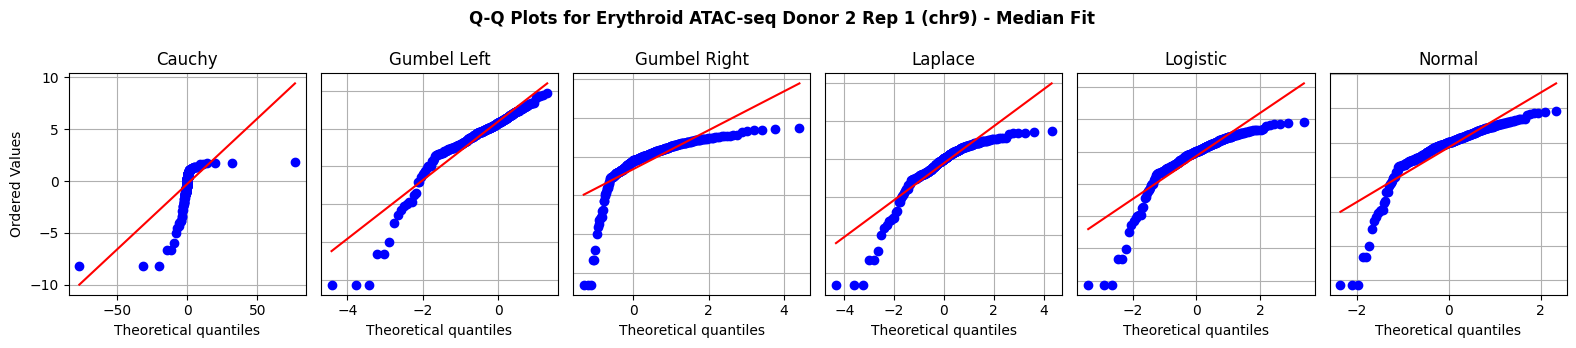

In [ ]:
# Create QQ plots for erythroid ATAC-seq
sample_name = "GSM9320314_Don002_ATAC_d13_rep1"
chromosome = "chr9"

ery_atac_znorm.plotQQPlot(plot_sample = sample_name,
                          chromosome = chromosome,
                          plot_width = 16,
                          plot_height = 3.5,
                          title = f"Q-Q Plots for Erythroid ATAC-seq Donor 2 Rep 1 ({chromosome}) - Median Fit",
                          pdf_name = f"{sample_name}_QQ_Plots")

#### 6.2.4) Distribution Fit Histograms

To assess how well each distribution fits the data per location and scale ($L_{c}$, $V_{c}$), histograms of transformed signal can be overlaid with fitted distributions per chromosome via `plotDistributionFit`.

| Parameter | Description | Usage |
|------------|-------------|-------------|
| **`plot_sample`** | Name of sample to create distribution fit plot for. | Required. |
| **`chromosome`** | Name of chromosome that distribution was fitted to signal for. | Required. |
| **`plot_distributions`** | List of distributions to include on each sub-plot. | By default, all distributions are plotted. |
| **`plot_param_types`** | List of location and scale parameter types. One sub-plot will be created per type. Options include `mean_fit` (mean and SD), `median_fit` (median and MAD), and `scipy_fit` (SciPy's recommended parameters). | By default, all parameter types are plotted. |
| **`zone_probability`** | A value between 0 and 1 that determines where to place the cut-off relative to the fitted distribution based on its cumulative probability. For example, $p = 0.995$ is the place where 99.5% of the distribution's signal lies to the left of the threshold (or flipped for negative signal). | If unset, the value is derived from the `ZoneNorm` instance. |
| **`pdf_name`** | If provided, the plot will be saved as a PDF with this name. | By default, plot is displayed but not saved. |

##### Erythroid ATAC-seq Example

Each sub-plot shows the histogram of transformed signal for a erythroid ATAC-seq replicate and a chromosome, with fitted distributions overlaid for each parameter type $(L_{c}$, $V_{c})$. This provides a visual comparison of how well each distribution matches the signal. For each fit, its log-transformed zone threshold, $ln(\lambda_{c})$, is shown for a zone probability ($p$).
* $\lambda_{c}$ is the cut-off used later to initially separate signal from background noise
* $p$ is the selected cumulative quantile of the fitted distribution at which to separate signal from background noise

Zone probability (p): 0.995


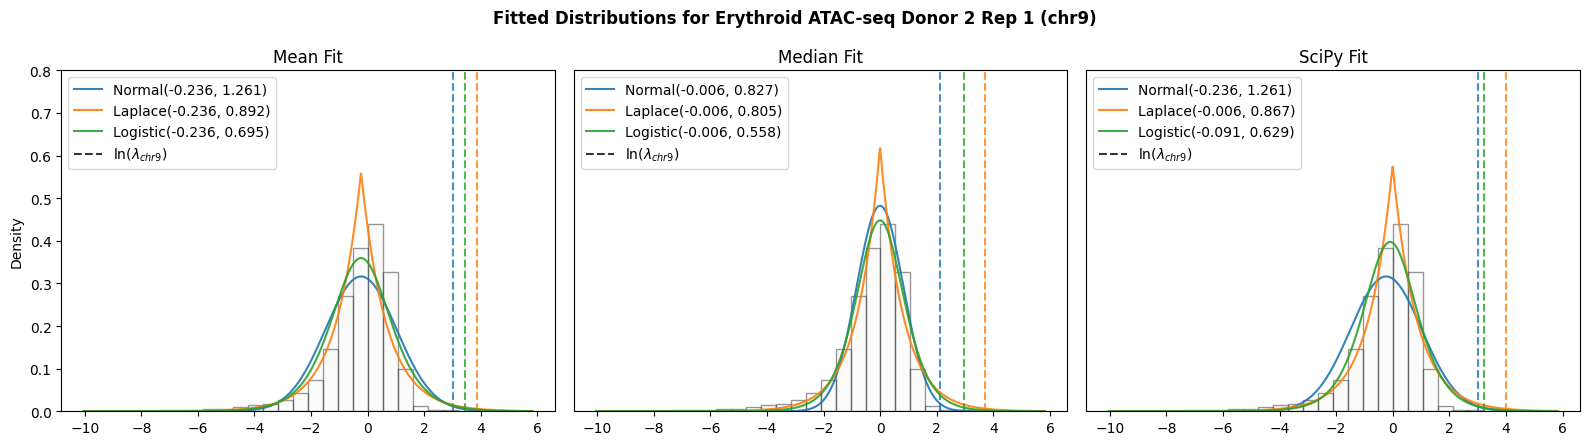

In [ ]:
sample_name = "GSM9320314_Don002_ATAC_d13_rep1"
chromosome = "chr9"

# Show the zone probability that the log-transformed zone threshold is based on
print("Zone probability (p):", ery_atac_znorm.getZoneProbability())

# Create distribution plots per sample
ery_atac_znorm.plotDistributionFit(plot_sample = sample_name,
                                   chromosome = chromosome,
                                   plot_distributions = ["normal", "laplace", "logistic"],
                                   plot_param_types = ["mean_fit", "median_fit", "scipy_fit"],
                                   y_limits = [0, 0.8],
                                   plot_width = 16,
                                   plot_height = 4.5,
                                   title = f"Fitted Distributions for Erythroid ATAC-seq Donor 2 Rep 1 ({chromosome})",
                                   pdf_name = f"{sample_name}_Distributions_{chromosome}")

#### 6.2.5) Visualising the Zone Threshold

The zone threshold $\lambda_{c}$ is derived by reversing the log-transformation of $ln(\lambda_{c})$. This creates a cut-off applied to the smoothed signal for the initial separatation of signal from background noise prior to quality filtering. 
* $\lambda_{c}$ varies depending on the fitted distribution, location, scale and zone probabilty $p$

The value of $\lambda_{c}$ for a fitted distribution can be accessed with `calculateZoneThreshold`.

| Parameter | Description | Usage |
|------------|-------------|-------------|
| **`sample`** | Sample name to calculate a zone threshold for. | Required. |
| **`chromosome`** | Chromosome name. | Required unless custom `location` and `scale` are given. |
| **`location`** | Value for distribution position. | Not required, but can be set to calculate $\lambda_{c}$ at a different location to the one derrived from distribution fitting. |
| **`scale`** | Value for distribution spread. | Not required, but can be set to calculate $\lambda_{c}$ at a different scale to the one derrived from distribution fitting. |
| **`dist_name`** | Distribution to derive the threshold from, e.g. `norm`, `logistic`, `laplace`, `gumbel_l`, `gumbel_r`, `cauchy`. | If unset, the value is derived from the `ZoneNorm` instance. |
| **`param_type`** | Parameter type for setting the distribution's location and scale, e.g. `mean_fit` (mean and SD), `median_fit` (median and MAD), and `scipy_fit` (SciPy's recommended parameters). | If unset, the value is derived from the `ZoneNorm` instance. |
| **`zone_probability`** | A value between 0 and 1 that determines where to place the cut-off relative to the fitted distribution based on its cumulative probability. For example, $p = 0.995$ is the place where 99.5% of the distribution's signal lies to the left of the threshold (or flipped for negative signal). | If unset, the value is derived from the `ZoneNorm` instance. |

##### Erythroid ATAC-seq Example

Calculating $\lambda_{c}$ for different distributions, while keeping other parameters constant, shows how distribution choice can alter the point at which candidate signal regions are initially considered enriched prior to quality filtering. 
* A higher $\lambda_{c}$ can produce less genome coverage in zones (regions of enriched signal)

Zone threshold for norm with median_fit and p = 0.995: 6.496581797475876
Zone threshold for laplace with median_fit and p = 0.995: 11.542399388351827
Zone threshold for logistic with median_fit and p = 0.995: 9.130080562664158
Zone threshold for gumbel_l with median_fit and p = 0.995: 3.558052157350758
Zone threshold for gumbel_r with median_fit and p = 0.995: 12.007303760304366


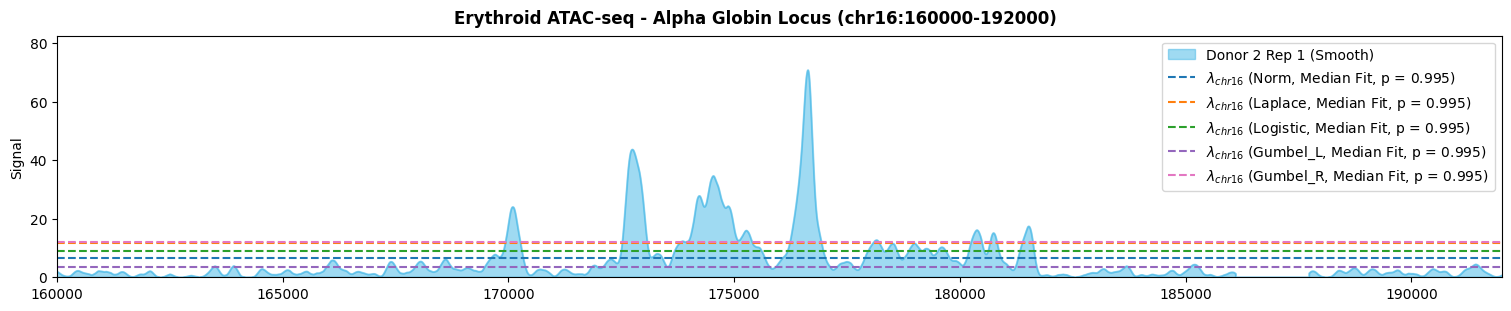

In [ ]:
sample_name = "GSM9320314_Don002_ATAC_d13_rep1"
chromosome = hg38_alpha_globin_coords["chrom"]

# Set colour for each distribution's zone threshold
dist_colour_map = {"norm": "#1f77b4",
                   "laplace": "#ff7f0e",
                   "logistic": "#2ca02c",
                   "gumbel_l": "#9467bd",
                   "gumbel_r": "#e377c2"}

dist_thresholds = []
dist_labels = []
dist_colours = []
param_type = "median_fit"
zone_probability = ery_atac_znorm.getZoneProbability()

for dist in ["norm", "laplace", "logistic", "gumbel_l", "gumbel_r"]:
    # Calculate zone threshold for a distribution at a fixed zone probability
    zone_threshold = ery_atac_znorm.calculateZoneThreshold(sample = sample_name, 
                                                           chromosome = chromosome,
                                                           dist_name = dist,
                                                           param_type = param_type, 
                                                           zone_probability = zone_probability)
    # Record the value, a label for the legend and the line colour for the plot below
    dist_thresholds.append(zone_threshold)
    dist_labels.append(f"$\lambda_{{{chromosome}}}$ ({dist.title()}, {param_type.title().replace('_', ' ')}, p = {zone_probability})")
    dist_colours.append(dist_colour_map[dist])

    print(f"Zone threshold for {dist} with {param_type} and p = {zone_probability}: {zone_threshold}")

# Plot smoothed signal and zone thresholds
title = f"Erythroid ATAC-seq - Alpha Globin Locus "
title += f"({hg38_alpha_globin_coords['chrom']}:{hg38_alpha_globin_coords['start']}-{hg38_alpha_globin_coords['end']})"

ery_atac_znorm.plotTracks(chromosome = hg38_alpha_globin_coords["chrom"],
                          start_coord = hg38_alpha_globin_coords["start"],
                          end_coord = hg38_alpha_globin_coords["end"],
                          plot_bigwigs = ["Erythroid_ATAC/Results/BigWigs/Smooth/GSM9320314_Don002_ATAC_d13_rep1_smooth.bw"],
                          plot_labels = ["Donor 2 Rep 1 (Smooth)"],
                          custom_colours = "#41B6E6",
                          overlay_plots = False,
                          main_title = title,
                          y_intercept = dist_thresholds,
                          y_intercept_labels = dist_labels,
                          y_intercept_colour = dist_colours)

As $p$ represents the cumulative probability from which $\lambda_{c}$ is derived, increasing $p$ therefore reduces the accepted level of background noise. 

Zone threshold for laplace with median_fit and p = 0.995: 9.756226060839811
Zone threshold for laplace with median_fit and p = 0.995: 11.542399388351827
Zone threshold for laplace with median_fit and p = 0.995: 15.689765419840414


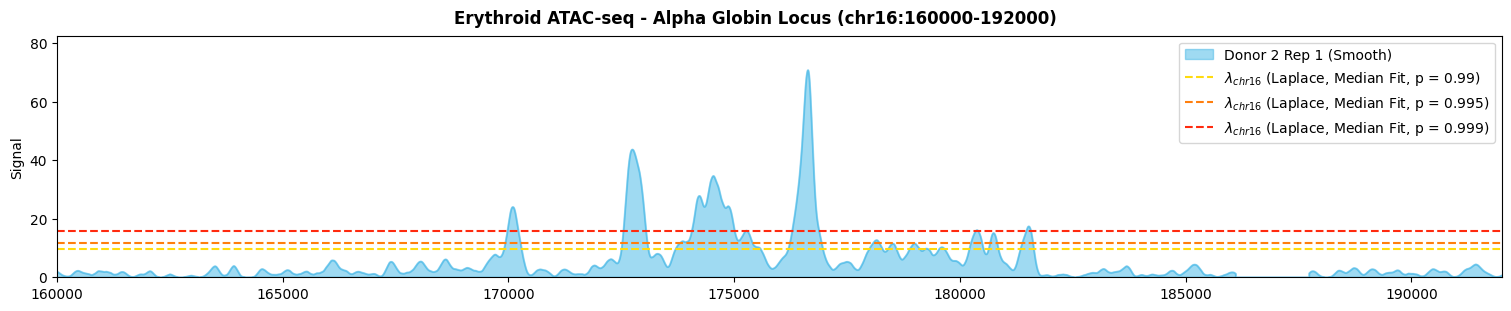

In [ ]:
sample_name = "GSM9320314_Don002_ATAC_d13_rep1"
chromosome = hg38_alpha_globin_coords["chrom"]

dist_thresholds = []
dist_labels = []
dist_colours = ["#ffdb0e", "#ff7f0e", "#ff2a0e"]
param_type = "median_fit"
dist = "laplace"

for p in [0.99, 0.995, 0.999]:
    # Calculate zone threshold for the same distribution, but at different zone probabilities
    zone_threshold = ery_atac_znorm.calculateZoneThreshold(sample = sample_name, 
                                                           chromosome = chromosome,
                                                           param_type = param_type, 
                                                           dist_name = dist,
                                                           zone_probability = p)
    # Record the value and a label for the legend
    dist_thresholds.append(zone_threshold)
    dist_labels.append(f"$\lambda_{{{chromosome}}}$ ({dist.title()}, {param_type.title().replace('_', ' ')}, p = {p})")

    print(f"Zone threshold for {dist} with {param_type} and p = {zone_probability}: {zone_threshold}")

# Plot smoothed signal and zone thresholds
title = f"Erythroid ATAC-seq - Alpha Globin Locus "
title += f"({hg38_alpha_globin_coords['chrom']}:{hg38_alpha_globin_coords['start']}-{hg38_alpha_globin_coords['end']})"

ery_atac_znorm.plotTracks(chromosome = hg38_alpha_globin_coords["chrom"],
                          start_coord = hg38_alpha_globin_coords["start"],
                          end_coord = hg38_alpha_globin_coords["end"],
                          plot_bigwigs = ["Erythroid_ATAC/Results/BigWigs/Smooth/GSM9320314_Don002_ATAC_d13_rep1_smooth.bw"],
                          plot_labels = ["Donor 2 Rep 1 (Smooth)"],
                          custom_colours = "#41B6E6",
                          overlay_plots = False,
                          main_title = title,
                          y_intercept = dist_thresholds,
                          y_intercept_labels = dist_labels,
                          y_intercept_colour = dist_colours)

#### 6.2.6) Setting the Distribution to Use for Zone Prediction

Although the default settings are recommended in most cases, they can be overridden either during initialisation of a `ZoneNorm` object, or using `setZoneDistribution`, `setZoneParamType` and `setZoneProbability`.

##### Alternative Distribution Parameters Example

For example, the distribution, parameter type and $p$ can explicity be set as follows.
* For demonstrative purposes, the default parameter are specified here

In [54]:
# Set specific distribution, parameter type and zone probability
ery_atac_znorm.setZoneDistribution(zone_distribution = "laplace")
ery_atac_znorm.setZoneParamType(zone_param_type = "median_fit")
ery_atac_znorm.setZoneProbability(zone_probability = 0.99)

### 6.3) Zone Prediction <a id="run-zen-zones"></a>

After distribution fitting, zone thresholds from the selected distribution are used to create signal zones. These are genomic regions enriched in signal over background noise. Two types of zones are produced: unpadded and padded.

<ins>Unpadded Zones</ins>

Unpadded zones are created by:
1. _Initial thresholding_: The absolute value of the smoothed signal is thresholded by $\lambda_{c}$ to retain positions exceeding it consecutively for $\geq r$ bp.
2. _Quality filtering_: Within each retained region, a quality threshold $\tau_{c}$ is applied across the absolute value of the original (unsmoothed) signal. Regions that exceed $\tau_{c}$ for $\geq m$ bp consecutive differences are considered unpadded zones.

<ins>Padded Zones</ins>

Padded zones are created from unpadded zones by:
1. _Merging nearby unpadded zones_: Combine coordinates of unpadded zones within $d$ bp.
2. _Edge Padding_: For each combined coordinate region, extend start and end by $b$ bp.
3. _Alignment to padding bins_: Rounded coordinates outwards to the nearest $b$ bp.
4. _Final merge_: Merge coordinates within $d$ bp forming padded zones.

#### 6.3.1) Quality Filter

When predicing unpadded zones, the initial thresholding step can call regions "enriched" even when a chromosome's signal is consistently noisy or sparse. This is because $\lambda_{c}$ is derived from splitting chromosome signal based on a quantile of the fitting distribution. To safeguard against this, quality filtering with $\tau_{c}$ ensures zones have sufficient signal relative to local and genome-wide averages, as well as a minimum number of reads.

Specifically, $\tau_{c}$ ensures that zones include signal that exceed:
* _Local average_: $1.5 \times \mu_{c}$, where $\mu_{c}$ is the mean of the non-zero signal per chromosome
* _Global average_: $1.5 \times \mu_{g}$, where $\mu_{g}$ is the mean of the non-zero signal across the genome
* _Cross-experiment minimum_: $10 \times \hat{f}$, where $\hat{f}$ estimates the signal value produced by a single read

##### Erythroid ATAC-seq Example

Chromosome Y is often sparse and consists of mainly background noise. In the example below, it can be seen that $\tau_{chrY}$ excludes most background noise regardless of what $\lambda_{chrY}$ evaluates as.

Quality threshold: 10.0


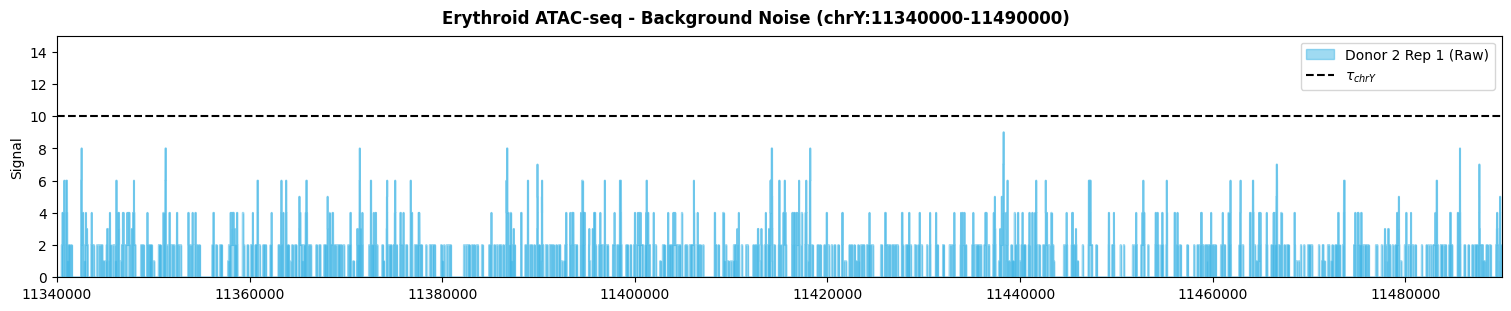

In [ ]:
sample_name = "GSM9320314_Don002_ATAC_d13_rep1"
chromosome = "chrY"
start = 11340000
end = 11490000

# Get quality thresholds per sample for the chromosome
quality_thresholds = ery_atac_znorm.calculateQualityThresholds(chromosome = chromosome)
sample_quality_threshold = quality_thresholds[sample_name]

print("Quality threshold:", sample_quality_threshold)

# Plot raw signal and quality threshold
title = f"Erythroid ATAC-seq - Background Noise "
title += f"({chromosome}:{start}-{end})"

ery_atac_znorm.plotTracks(chromosome = chromosome,
                          start_coord = start,
                          end_coord = end,
                          plot_samples = sample_name,
                          plot_labels = ["Donor 2 Rep 1 (Raw)"],
                          custom_colours = "#41B6E6",
                          overlay_plots = False,
                          main_title = title,
                          y_intercept = sample_quality_threshold,
                          y_intercept_labels = f"$\\tau_{{{chromosome}}}$",
                          y_intercept_colour = "black",
                          custom_y = [0, 15])

#### 6.3.2) Predicting Zones

To create unpadded and padded zones using the selected distribution, parameter type and $p$, run `predictSignalZones`.

| Parameter | Description | Usage |
|------------|-------------|-------------|
| **`chromosomes`** | List of chromosomes to predict signal zones for. | By default, all chromosomes are used. |
| **`replace_existing`** | If `True`, existing output files will be recreated. If `False`, only missing files will be generated without overwriting existing ones. | `False` by default. Set as `True` if a previous run was interrupted and produced incomplete or corrupt files. |

##### Erythroid ATAC-seq Example

Predict unpadded and padded signal zones

In [6]:
# Predict signal zone coordinates
ery_atac_znorm.predictSignalZones()

Signal and merged zone files already created for chromosomes


Get unpadded and padded zones per sample, as well as zones merged across all samples

In [3]:
# Get unpadded and padded zones per sample
sample_zones_df = []
# Get unpadded and padded zones merged across all samples
merged_zones_df = []

for chrom in ery_atac_znorm.getChromosomes():
    # Get zones for the chromosome
    sample_zones_df.append(ery_atac_znorm.getSampleZones(chrom))
    merged_zones_df.append(ery_atac_znorm.getMergedZones(chrom))

# Combine into DataFrames
sample_zones_df = pd.concat(sample_zones_df)
merged_zones_df = pd.concat(merged_zones_df)

# View sample-specific zones
sample_zones_df

,zone_type,sample,chrom,start,end
0,unpadded,GSM9320314_Don002_ATAC_d13_rep1,chr1,10008,10509
1,unpadded,GSM9320314_Don002_ATAC_d13_rep1,chr1,11168,11441
2,unpadded,GSM9320314_Don002_ATAC_d13_rep1,chr1,29065,29482
3,unpadded,GSM9320314_Don002_ATAC_d13_rep1,chr1,32450,32882
4,unpadded,GSM9320314_Don002_ATAC_d13_rep1,chr1,34375,34571
...,...,...,...,...,...
4251,padded_1000,GSM9320327_Don003_ATAC_d13_rep7,chrY,56859000,56862000
4252,padded_1000,GSM9320327_Don003_ATAC_d13_rep7,chrY,56865000,56869000
4253,padded_1000,GSM9320327_Don003_ATAC_d13_rep7,chrY,56871000,56874000
4254,padded_1000,GSM9320327_Don003_ATAC_d13_rep7,chrY,56876000,56879000


#### 6.3.3) Saving Zones to BED Files <a id="run-zen-zone-bed"></a>

Zone coordinates can be saved to BED files with `createZoneBED`. These can be viewed in a genome browser.

| Parameter | Description | Usage |
|------------|-------------|-------------|
| **`zone_type`** | Can be set as either `padded` (default) or `unpadded`. | Padded zones are recommended, and for this the parameter can be left unset. |

##### Erythroid ATAC-seq Example

In [28]:
# Save zone coordinates to BED files
ery_atac_znorm.createZoneBED()

Saving zones to BED files


#### 6.3.4) Visualising Zones

Zones can be plotted as bars above signal using `plotTracks`.

##### Erythroid ATAC-seq Example

For example, unpadded and padded zones are shown below for erythroid ATAC-seq donor 2 replicate 1.
* The upper sub-plot shows the unpadded zones, smoothed signal and zone threshold $\lambda_{chr16}$
* The lower sub-plot shows the padded zones, original (unsmoothed) signal and quality filter threshold $\tau_{chr16}$

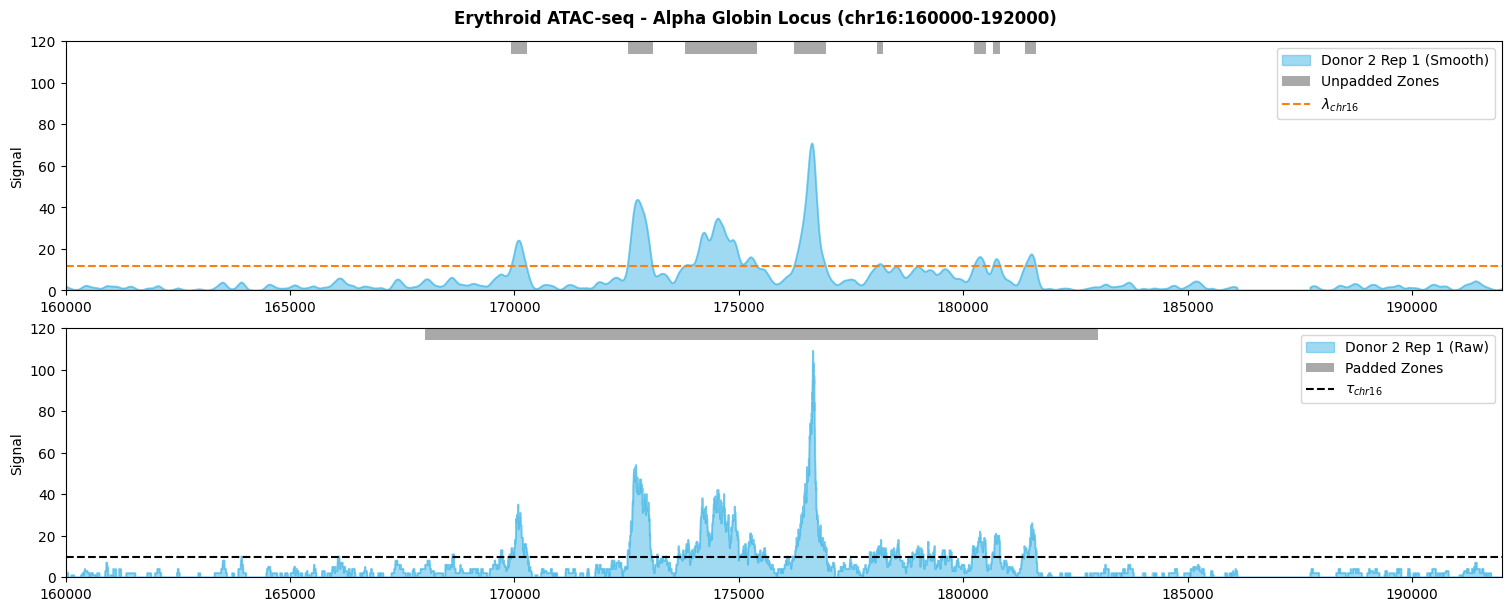

In [ ]:
sample_name = "GSM9320314_Don002_ATAC_d13_rep1"
chromosome = hg38_alpha_globin_coords["chrom"]

# Get the zone threshold from the fitted distribution
zone_threshold = ery_atac_znorm.calculateZoneThreshold(sample = sample_name, chromosome = chromosome)
# Get quality threshold
quality_threshold = ery_atac_znorm.calculateQualityThresholds(chromosome = chromosome)[sample_name]

# Get coordinates of unpadded and padded sample-specific zones
pad_bin_size = ery_atac_znorm.getPadBinSize()

sample_zones = sample_zones_df[(sample_zones_df["sample"] == sample_name) &
                               (sample_zones_df["chrom"] == chromosome)]
unpadded_zones = sample_zones[(sample_zones["zone_type"] == "unpadded")][["start", "end"]].values
padded_zones = sample_zones[(sample_zones["zone_type"] == f"padded_{pad_bin_size}")][["start", "end"]].values

# Plot the raw and smoothed signal, zones and thresholds
title = f"Erythroid ATAC-seq - Alpha Globin Locus "
title += f"({hg38_alpha_globin_coords['chrom']}:{hg38_alpha_globin_coords['start']}-{hg38_alpha_globin_coords['end']})"

ery_atac_znorm.plotTracks(chromosome = hg38_alpha_globin_coords["chrom"],
                          start_coord = hg38_alpha_globin_coords["start"],
                          end_coord = hg38_alpha_globin_coords["end"],
                          plot_bigwigs = ["Erythroid_ATAC/Results/BigWigs/Smooth/GSM9320314_Don002_ATAC_d13_rep1_smooth.bw",
                                          "Example_Data/Erythroid_ATAC/BigWigs/GSM9320314_Don002_ATAC_d13_rep1.bw"],
                          plot_labels = ["Donor 2 Rep 1 (Smooth)", "Donor 2 Rep 1 (Raw)"],
                          custom_colours = "#41B6E6",
                          main_title = title,
                          y_intercept = [zone_threshold, quality_threshold],
                          y_intercept_labels = [f"$\lambda_{{{chromosome}}}$", f"$\\tau_{{{chromosome}}}$"],
                          y_intercept_colour = ["#ff7f0e", "black"],
                          share_y_intercepts = False,
                          bar_regions = [unpadded_zones, padded_zones],
                          bar_labels = ["Unpadded Zones", "Padded Zones"],
                          bar_colour = "darkgrey",
                          custom_y = [0, 120])

### 6.4) Normalised bigWig Generation <a id="run-zen-norm"></a>

After zone prediction, ZEN normalised bigWigs can be created by scaling the original signal by statistics calculated from signal within zones.

#### 6.4.1) Creating ZEN Normalised bigWigs

`normaliseSignal` normalises all chromosomes and saves this signal to bigWigs.

| Parameter | Description | Usage |
|------------|-------------|-------------|
| **`replace_existing`** | If set as `True`, any existing output files generated by this method will be recreated. This is useful if a previous run was interrupted and produced incomplete or corrupt files. If `False` (default), only missing files will be generated without overwriting existing ones. | Use only to recreate files after a previous run. |

##### Erythroid ATAC-seq Example

Save ZEN bigWigs.

In [55]:
# Create normalised bigWigs
ery_atac_znorm.normaliseSignal()

Full ZEN normalised signal already created


View ZEN normalised signal over a region with `plotTracks`.

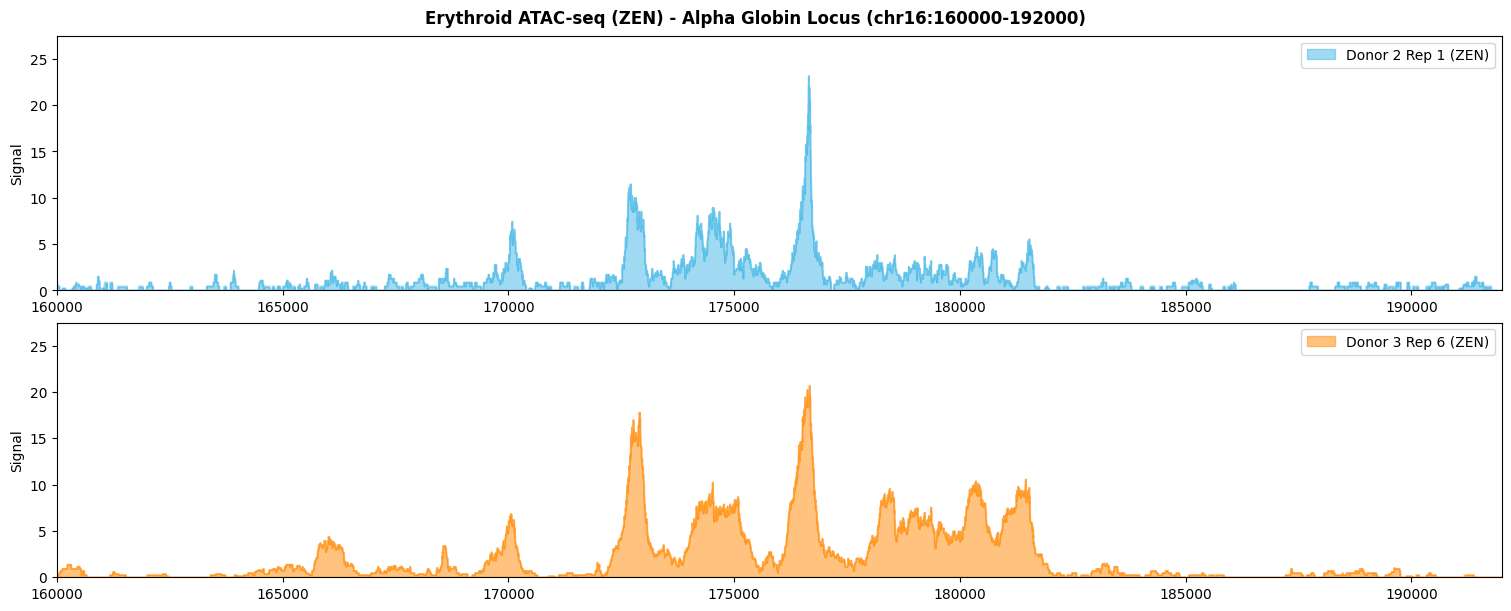

In [7]:
# Plot the signal
title = f"Erythroid ATAC-seq (ZEN) - Alpha Globin Locus "
title += f"({hg38_alpha_globin_coords['chrom']}:{hg38_alpha_globin_coords['start']}-{hg38_alpha_globin_coords['end']})"

ery_atac_znorm.plotTracks(chromosome = hg38_alpha_globin_coords["chrom"],
                          start_coord = hg38_alpha_globin_coords["start"],
                          end_coord = hg38_alpha_globin_coords["end"],
                          plot_bigwigs = ["Erythroid_ATAC/Results/BigWigs/ZEN/GSM9320314_Don002_ATAC_d13_rep1_ZEN.bw",
                                          "Erythroid_ATAC/Results/BigWigs/ZEN/GSM9320326_Don003_ATAC_d13_rep6_ZEN.bw"],
                          plot_labels = ["Donor 2 Rep 1 (ZEN)", "Donor 3 Rep 6 (ZEN)"], 
                          custom_colours = ["#41B6E6", "#FF8800"],
                          overlay_plots = False,
                          main_title = title)